# Check Optimal Confidence Threshold

This notebook loads a trained YOLO weight and computes the optimal confidence threshold for scoring.

In [2]:
# Cell 2: imports and project path setup
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dagri.general.config_manager import ConfigManager
from dagri.data import CustomDataset
from dagri.baseline import Baseline

In [3]:
# Cell 3: set input paths
CONFIG_PATH = Path("../configs/experiments/minneapple_yolo.yaml")
MODEL_WEIGHT_PATH = Path("../results/01_minneapple_yolo_copy_paste_augmentation_detection/Step_2_Train_and_Evaluate_BASELINE_MODEL/train_results/best.pt")

print(f"Config path: {CONFIG_PATH.resolve()}")
print(f"Model weight path: {MODEL_WEIGHT_PATH.resolve()}")
print(f"Config exists: {CONFIG_PATH.exists()}")
print(f"Model weight exists: {MODEL_WEIGHT_PATH.exists()}")

Config path: /home/khanh/Projects/DifficultyAgri/configs/experiments/minneapple_yolo.yaml
Model weight path: /home/khanh/Projects/DifficultyAgri/results/01_minneapple_yolo_copy_paste_augmentation_detection/Step_2_Train_and_Evaluate_BASELINE_MODEL/train_results/best.pt
Config exists: True
Model weight exists: True


In [4]:
# Cell 4: load experiment configuration
config_manager = ConfigManager()
config_manager.load_all_configs(str(CONFIG_PATH))

initial_dataset_config = config_manager.initial_dataset_config
baseline_model_config = config_manager.baseline_config

print("Configuration loaded")

Configuration loaded


In [5]:
# Cell 5: initialize dataset and extract properties
initial_dataset = CustomDataset(initial_dataset_config)
initial_dataset.validate()
initial_dataset_properties = initial_dataset.get_properties()

print("Dataset validated and properties extracted")

Dataset validated and properties extracted


In [6]:
# Cell 6: initialize baseline model
baseline_model = Baseline(baseline_model_config)
print("Baseline model initialized")

Baseline model initialized


In [7]:
# Cell 7: find optimal confidence threshold
print("Finding optimal confidence threshold...")

optimal_conf_threshold = baseline_model.get_optimal_conf_threshold_for_scoring(
    dataset_properties=initial_dataset_properties,
    model_weight=str(MODEL_WEIGHT_PATH),
    conf_min=0.001,
    conf_max=0.9,
    num_points=20,
)

print(f"Optimal confidence threshold: {optimal_conf_threshold}")

Finding optimal confidence threshold...
Ultralytics 8.4.21 🚀 Python-3.13.7 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Workstation Edition, 97248MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 11886.0±1500.9 MB/s, size: 1438.2 KB)
val: Scanning /home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/val/labels.cache... 134 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 134/134 70.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 23.4it/s 0.4s0.4s
                   all        134       5367       0.87      0.842      0.904      0.478
Speed: 0.3ms preprocess, 1.1ms inference, 0.0ms loss, 0.3ms postprocess per image
Ultralytics 8.4.21 🚀 Python-3.13.7 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Workstation Edition, 97248MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, re

## Compare Alternative Threshold Selection Methods

Current method in codebase chooses confidence threshold by maximizing **validation mAP50**.

This is valid, but you can compare against other criteria:
- maximize mAP50-95 (stricter localization quality)
- maximize F1 (balance precision/recall)

Run the next cell to sweep confidence and compare all criteria on the same validation split.

Ultralytics 8.4.21 🚀 Python-3.13.7 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Workstation Edition, 97248MiB)
YOLOv8s summary (fused): 72 layers, 11,156,544 parameters, 0 gradients, 28.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 11798.6±1670.0 MB/s, size: 1451.8 KB)
val: Scanning /home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/val/labels.cache... 134 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 134/134 70.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 13.4it/s 0.7s0.1s
                   all        134       5367     0.0306    0.00186     0.0153    0.00797
Speed: 0.4ms preprocess, 1.0ms inference, 0.0ms loss, 0.5ms postprocess per image
Ultralytics 8.4.21 🚀 Python-3.13.7 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Workstation Edition, 97248MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7542.5±4486.0 MB/s, size: 1452.9 K

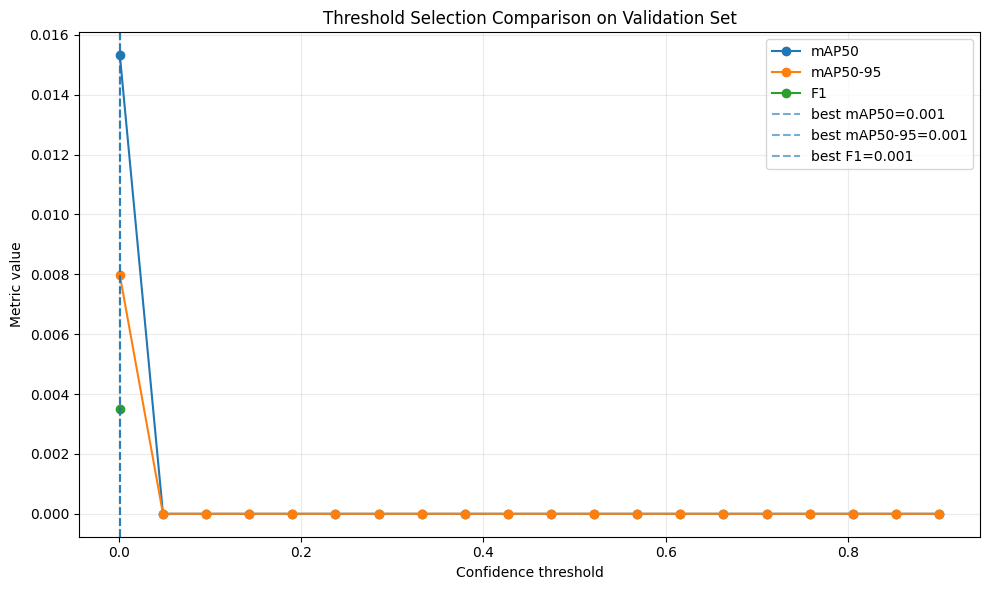

In [8]:
# Cell 9: sweep confidence and compare methods
import tempfile
import numpy as np
import matplotlib.pyplot as plt

# You can make this denser (e.g., 30-50) for more precise selection
thresholds = np.linspace(0.001, 0.9, 20)

# Access underlying YOLO model and helper from your baseline wrapper
yolo_impl = baseline_model.model            # YoloUltralyticsModel
yolo_model = yolo_impl.model                # ultralytics.YOLO

rows = []

with tempfile.TemporaryDirectory(prefix="conf_compare_") as tmp_dir:
    data_path = yolo_impl._create_data_yaml(initial_dataset_properties, tmp_dir)

    for conf in thresholds:
        val_kwargs = {
            "data": data_path,
            "split": "val",
            "conf": float(conf),
            "save_json": False,
            "plots": False,
            "verbose": False,
        }

        if yolo_impl.evaluation_config.image_size is not None:
            val_kwargs["imgsz"] = yolo_impl.evaluation_config.image_size
        if yolo_impl.evaluation_config.iou_threshold is not None:
            val_kwargs["iou"] = yolo_impl.evaluation_config.iou_threshold
        if yolo_impl.evaluation_config.max_detections is not None:
            val_kwargs["max_det"] = yolo_impl.evaluation_config.max_detections

        val_result = yolo_model.val(**val_kwargs)

        box = getattr(val_result, "box", None)
        results_dict = getattr(val_result, "results_dict", None) or {}

        # Robust extraction across ultralytics versions
        map50 = float(getattr(box, "map50", np.nan)) if box is not None else float(results_dict.get("metrics/mAP50(B)", np.nan))
        map5095 = float(getattr(box, "map", np.nan)) if box is not None else float(results_dict.get("metrics/mAP50-95(B)", np.nan))
        precision = float(getattr(box, "mp", np.nan)) if box is not None else float(results_dict.get("metrics/precision(B)", np.nan))
        recall = float(getattr(box, "mr", np.nan)) if box is not None else float(results_dict.get("metrics/recall(B)", np.nan))

        if np.isnan(precision) or np.isnan(recall) or (precision + recall) == 0:
            f1 = np.nan
        else:
            f1 = 2.0 * precision * recall / (precision + recall)

        rows.append({
            "conf": float(conf),
            "map50": map50,
            "map50_95": map5095,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

# Convert to arrays for analysis
conf_arr = np.array([r["conf"] for r in rows], dtype=float)
map50_arr = np.array([r["map50"] for r in rows], dtype=float)
map5095_arr = np.array([r["map50_95"] for r in rows], dtype=float)
f1_arr = np.array([r["f1"] for r in rows], dtype=float)

best_map50_idx = int(np.nanargmax(map50_arr))
best_map5095_idx = int(np.nanargmax(map5095_arr))
best_f1_idx = int(np.nanargmax(f1_arr))

best_by_map50 = conf_arr[best_map50_idx]
best_by_map5095 = conf_arr[best_map5095_idx]
best_by_f1 = conf_arr[best_f1_idx]

print("Best thresholds by criterion:")
print(f"- mAP50      : {best_by_map50:.4f} (score={map50_arr[best_map50_idx]:.4f})")
print(f"- mAP50-95   : {best_by_map5095:.4f} (score={map5095_arr[best_map5095_idx]:.4f})")
print(f"- F1         : {best_by_f1:.4f} (score={f1_arr[best_f1_idx]:.4f})")
print(f"- Current code method returned: {optimal_conf_threshold:.4f}")

# Visualize metric-vs-threshold curves
plt.figure(figsize=(10, 6))
plt.plot(conf_arr, map50_arr, marker="o", label="mAP50")
plt.plot(conf_arr, map5095_arr, marker="o", label="mAP50-95")
plt.plot(conf_arr, f1_arr, marker="o", label="F1")

plt.axvline(best_by_map50, linestyle="--", alpha=0.6, label=f"best mAP50={best_by_map50:.3f}")
plt.axvline(best_by_map5095, linestyle="--", alpha=0.6, label=f"best mAP50-95={best_by_map5095:.3f}")
plt.axvline(best_by_f1, linestyle="--", alpha=0.6, label=f"best F1={best_by_f1:.3f}")

plt.xlabel("Confidence threshold")
plt.ylabel("Metric value")
plt.title("Threshold Selection Comparison on Validation Set")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()